In [20]:
%load_ext autoreload
%autoreload 2
# Cell 1 in your Jupyter Notebook
import sys
import os

# Point Python to the main icetmosphere folder
sys.path.append(os.path.abspath('..'))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
from atm_tools import alpha_specific_function
from class_and_spt_emission import compute_T_RJ_ice2, compute_T_RJ_ice_CLASS1, compute_depolarization_factor
from scipy import constants
import pycraf
from astropy import units as u

import matplotlib.pyplot as plt
import numpy as np

# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})

In [22]:
altitudes = np.linspace(1, 10000, 500) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en hPa
dz = np.diff(altitudes) # Shape: (len(altitudes)-1,)
frequency_ghz = np.array([90, 150, 220]) # GHz
frequency = frequency_ghz * 1e9 # Hz

pi = constants.pi 
c = constants.c
rho_ice = 917 #kg/m^3

elevation = 45 #degrees
IWP = 1e-3 #kg/m2

layer_bottom = 6000  # Bottom of the ice cloud layer in meters (example)
layer_top = 7000     # Top of the ice cloud layer in meters (example)
cloud_thickness = layer_top - layer_bottom # Thickness of the ice cloud layer in meters

r_eq = np.arange(1e-6, 200e-6, 5e-6)

# 3. Calculate d(IWP)/dz (which is the Ice Water Content)
# For a uniform cloud, it is just Total IWP / thickness
IWC_constant = IWP / cloud_thickness # kg/m^3

# Create the IWC profile (0 everywhere except in the cloud)
IWC_profile = np.where((altitudes >= layer_bottom) & (altitudes <= layer_top), IWC_constant, 0.0)
# Shape of IWC_profile is (Nz,)

# 4. Compute Volume of the crystals for all radii
V = (4.0 / 3.0) * np.pi * r_eq**3 # Shape: (Na,)

# 5. Compute the ice density n(z, r_eq) using Broadcasting
# We use [:, None] to make IWC a column (Nz, 1) 
# We use [None, :] to make V a row (1, Na)
# The result is a 2D grid of shape (Nz, Na)
n = IWC_profile[:, None] / (rho_ice * V[None, :])

#We could normalize PWV to 1 mm

The goal here is to compare each effects separetly, we no longer compare the methods, the CLASS one is valid now
Effects to compare: 
- Rayleigh Scattering of ground thermal emission
- Rayleigh Scattering of atmospheric thermal emission
- Emission from the ice-crystals

For the Rayleigh Scattering, it would be interesting to see the effect of Earth curvature

In [23]:
# Let's do it for the stokes parameter I
m_sphere = 1.0

I_RJ_scattering_tot_earth_curv =  compute_T_RJ_ice_CLASS1(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, 
                            r_eq, aspect_ratio=m_sphere, stokes_param='I', consider_earth_curvature=True, consider_atmospheric_emission=True)
I_RJ_scattering_tot_flat_earth =  compute_T_RJ_ice_CLASS1(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, 
                            r_eq, aspect_ratio=m_sphere, stokes_param='I', consider_earth_curvature=False, consider_atmospheric_emission=True)

I_RJ_scattering_ground_earth_curv =  compute_T_RJ_ice_CLASS1(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, 
                            r_eq, aspect_ratio=m_sphere, stokes_param='I', consider_earth_curvature=True, consider_atmospheric_emission=False)
I_RJ_scattering_ground_flat_earth =  compute_T_RJ_ice_CLASS1(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, 
                            r_eq, aspect_ratio=m_sphere, stokes_param='I', consider_earth_curvature=False, consider_atmospheric_emission=False)

I_RJ_scattering_atmos_earth_curv =  I_RJ_scattering_tot_earth_curv - I_RJ_scattering_ground_earth_curv
I_RJ_scattering_atmos_flat_earth =  I_RJ_scattering_tot_flat_earth - I_RJ_scattering_ground_flat_earth

I_RJ_emission = compute_T_RJ_ice2(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq, aspect_ratio=m_sphere, process='emission', stokes_param='I') #Shape (Nf, Na)


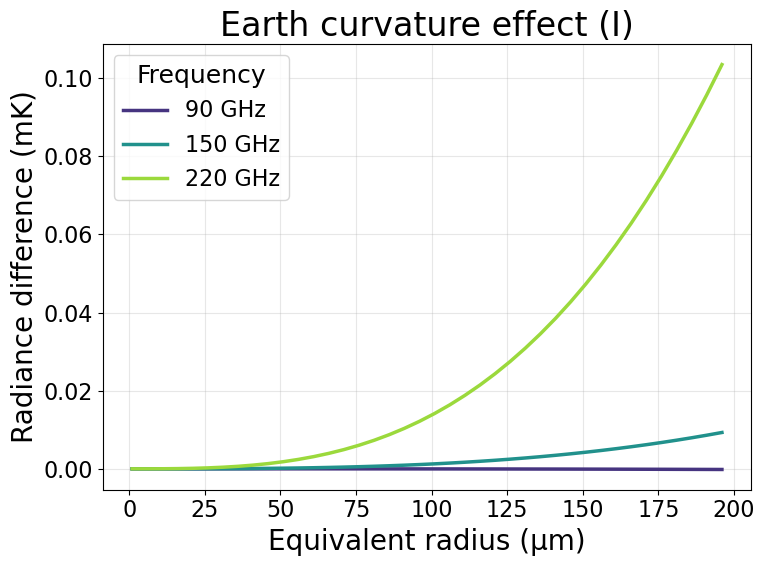

In [29]:
# Compare the Earth-curvature effect on total Rayleigh scattering for each frequency
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(frequency_ghz)))

for i, freq in enumerate(frequency_ghz):
    delta_scattering = I_RJ_scattering_tot_earth_curv[i, :, 0] - I_RJ_scattering_tot_flat_earth[i, :, 0]
    ax.plot(
        r_eq * 1e6,
        delta_scattering*1e3,  # Convert to mK_RJ for better visibility
        color=colors[i],
        linewidth=2.5,
        label=f'{freq} GHz',
    )

ax.set_xlabel('Equivalent radius (μm)')
ax.set_ylabel('Radiance difference (mK)')
ax.set_title('Earth curvature effect (I)')
ax.grid(True, alpha=0.3)
ax.legend(title='Frequency')
fig.tight_layout()

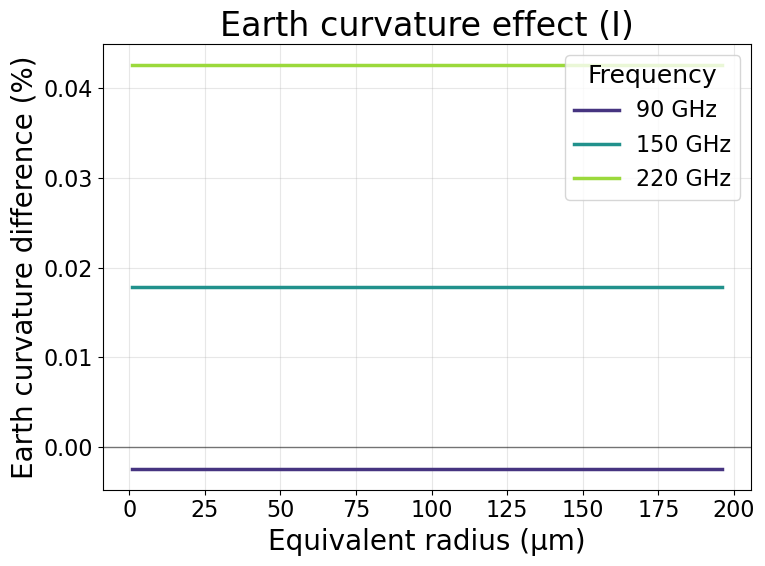

In [28]:
# Compare the Earth-curvature effect on total Rayleigh scattering in percent for each frequency
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(frequency_ghz)))

for i, freq in enumerate(frequency_ghz):
    flat = I_RJ_scattering_tot_flat_earth[i, :, 0]
    delta_percent = np.where(flat != 0, 100.0 * (I_RJ_scattering_tot_earth_curv[i, :, 0] - flat) / flat, np.nan)
    ax.plot(
        r_eq * 1e6,
        delta_percent,
        color=colors[i],
        linewidth=2.5,
        label=f'{freq} GHz',
    )

ax.axhline(0, color='k', linewidth=1, alpha=0.5)
ax.set_xlabel('Equivalent radius (μm)')
ax.set_ylabel('Earth curvature difference (%)')
ax.set_title('Earth curvature effect (I)')
ax.grid(True, alpha=0.3)
ax.legend(title='Frequency')
fig.tight_layout()

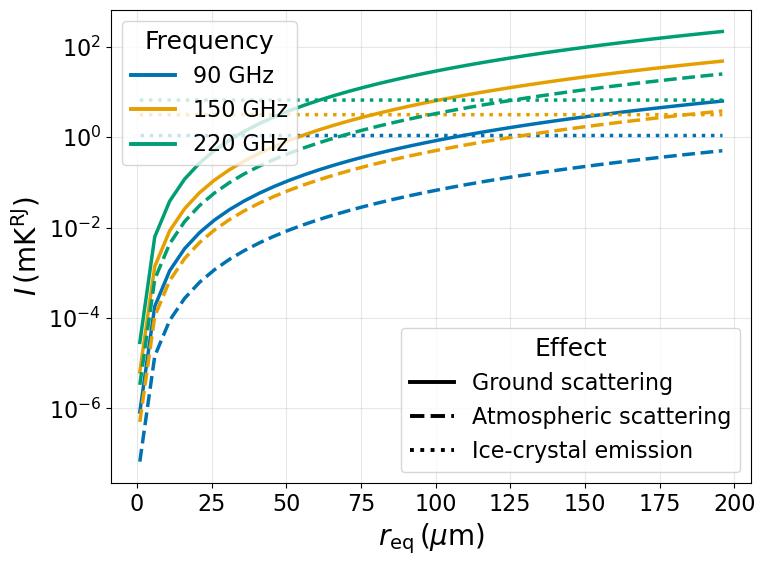

In [37]:
# Unified comparison: color encodes frequency, line style encodes physical effect
from matplotlib.lines import Line2D

y_log_scale = True  # Set to True for logarithmic y-axis

fig, ax = plt.subplots(figsize=(8, 6))

# High-contrast, colorblind-friendly palette (Okabe-Ito)
freq_colors = ['#0072B2', '#E69F00', '#009E73']  # blue, orange, green

if len(frequency_ghz) > len(freq_colors):
    # Fallback for more frequencies while keeping strong contrast
    freq_colors = list(plt.cm.tab10(np.linspace(0, 1, len(frequency_ghz))))

effects = [
    ('Ground scattering', I_RJ_scattering_ground_earth_curv, '-'),
    ('Atmospheric scattering', I_RJ_scattering_atmos_earth_curv, '--'),
    ('Ice-crystal emission', I_RJ_emission, ':'),
]

for i, freq in enumerate(frequency_ghz):
    for effect_name, data, linestyle in effects:
        y_mk = data[i, :] * 1e3  # Convert K_RJ -> mK_RJ
        y_plot = np.where(y_mk > 0, y_mk, np.nan) if y_log_scale else y_mk
        ax.plot(
            r_eq * 1e6,
            y_plot,
            color=freq_colors[i],
            linestyle=linestyle,
            linewidth=2.5,
        )

if y_log_scale:
    ax.set_yscale('log')

ax.set_xlabel(r'$r_{\mathrm{eq}}\,(\mu\mathrm{m})$')
ax.set_ylabel(r'$I\,(\mathrm{mK}^{\mathrm{RJ}})$')
#ax.set_title('Earth-curvature-aware contributions')
ax.grid(True, alpha=0.3)

# Build separate legends to explain both visual encodings.
freq_handles = [
    Line2D([0], [0], color=freq_colors[i], lw=2.8, linestyle='-', label=f'{freq} GHz')
    for i, freq in enumerate(frequency_ghz)
]
effect_handles = [
    Line2D([0], [0], color='black', lw=2.8, linestyle=linestyle, label=effect_name)
    for effect_name, _, linestyle in effects
]

legend_freq = ax.legend(handles=freq_handles, title='Frequency', loc='upper left')
ax.add_artist(legend_freq)
ax.legend(handles=effect_handles, title='Effect', loc='lower right')

fig.tight_layout()

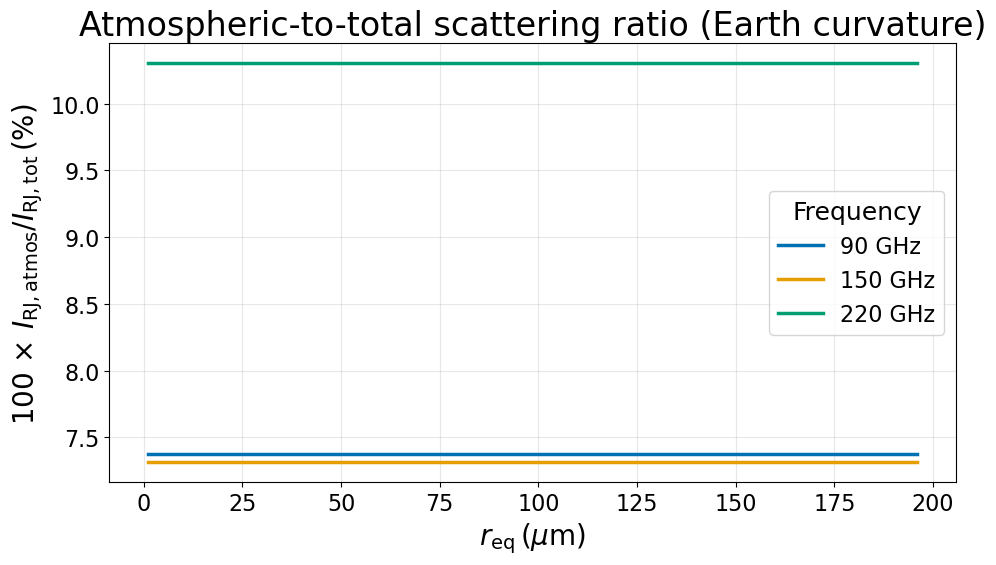

In [10]:
# Percentage contribution of atmospheric scattering to total scattering (Earth-curvature case)
fig, ax = plt.subplots(figsize=(10, 6))

# Keep the same high-contrast frequency colors
freq_colors = ['#0072B2', '#E69F00', '#009E73']
if len(frequency_ghz) > len(freq_colors):
    freq_colors = list(plt.cm.tab10(np.linspace(0, 1, len(frequency_ghz))))

for i, freq in enumerate(frequency_ghz):
    total = I_RJ_scattering_tot_earth_curv[i, :, 0]
    atmos = I_RJ_scattering_atmos_earth_curv[i, :, 0]
    percent = np.where(total != 0, 100.0 * atmos / total, np.nan)

    ax.plot(
        r_eq * 1e6,
        percent,
        color=freq_colors[i],
        linewidth=2.5,
        label=f'{freq} GHz',
    )

ax.set_xlabel(r'$r_{\mathrm{eq}}\,(\mu\mathrm{m})$')
ax.set_ylabel(r'$100\,\times\,I_{\mathrm{RJ,atmos}}/I_{\mathrm{RJ,tot}}\,(\%)$')
ax.set_title('Atmospheric-to-total scattering ratio (Earth curvature)')
ax.grid(True, alpha=0.3)
ax.legend(title='Frequency')
fig.tight_layout()

In [30]:
#Let's do it for the stokes parameter Q as well
Q_RJ_scattering_tot_earth_curv =  compute_T_RJ_ice_CLASS1(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, 
                            r_eq, aspect_ratio=m_sphere, stokes_param='Q', consider_earth_curvature=True, consider_atmospheric_emission=True)
Q_RJ_scattering_tot_flat_earth =  compute_T_RJ_ice_CLASS1(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, 
                            r_eq, aspect_ratio=m_sphere, stokes_param='Q', consider_earth_curvature=False, consider_atmospheric_emission=True)  

Q_RJ_scattering_ground_earth_curv =  compute_T_RJ_ice_CLASS1(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, 
                            r_eq, aspect_ratio=m_sphere, stokes_param='Q', consider_earth_curvature=True, consider_atmospheric_emission=False)
Q_RJ_scattering_ground_flat_earth =  compute_T_RJ_ice_CLASS1(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, 
                            r_eq, aspect_ratio=m_sphere, stokes_param='Q', consider_earth_curvature=False, consider_atmospheric_emission=False)

Q_RJ_scattering_atmos_earth_curv =  Q_RJ_scattering_tot_earth_curv - Q_RJ_scattering_ground_earth_curv
Q_RJ_scattering_atmos_flat_earth =  Q_RJ_scattering_tot_flat_earth - Q_RJ_scattering_ground_flat_earth

Q_RJ_emission = compute_T_RJ_ice2(frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq, aspect_ratio=m_sphere, process='emission', stokes_param='Q') #Shape (Nf, Na)

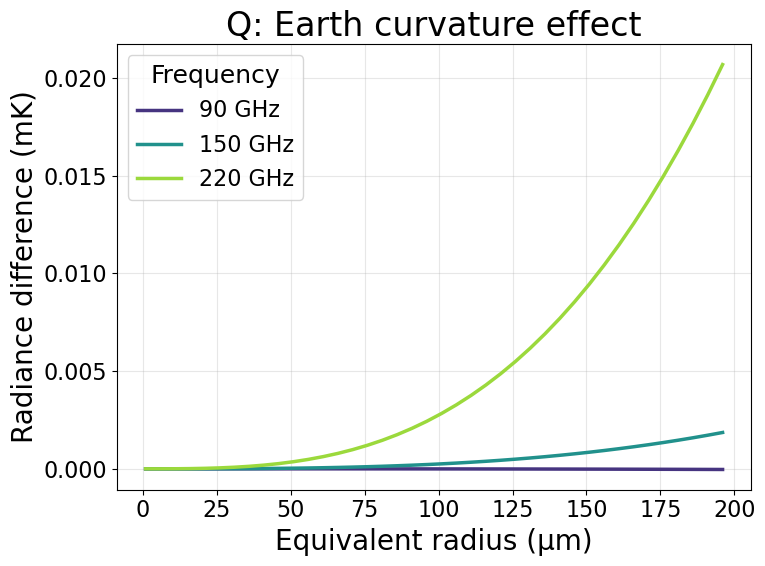

In [33]:
# Q: Compare the Earth-curvature effect on total Rayleigh scattering for each frequency
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(frequency_ghz)))

for i, freq in enumerate(frequency_ghz):
    delta_scattering_q = Q_RJ_scattering_tot_earth_curv[i, :, 0] - Q_RJ_scattering_tot_flat_earth[i, :, 0]
    ax.plot(
        r_eq * 1e6,
        delta_scattering_q * 1e3,  # Convert to mK_RJ for better visibility
        color=colors[i],
        linewidth=2.5,
        label=f'{freq} GHz',
    )

ax.set_xlabel('Equivalent radius (μm)')
ax.set_ylabel('Radiance difference (mK)')
ax.set_title('Q: Earth curvature effect')
ax.grid(True, alpha=0.3)
ax.legend(title='Frequency')
fig.tight_layout()

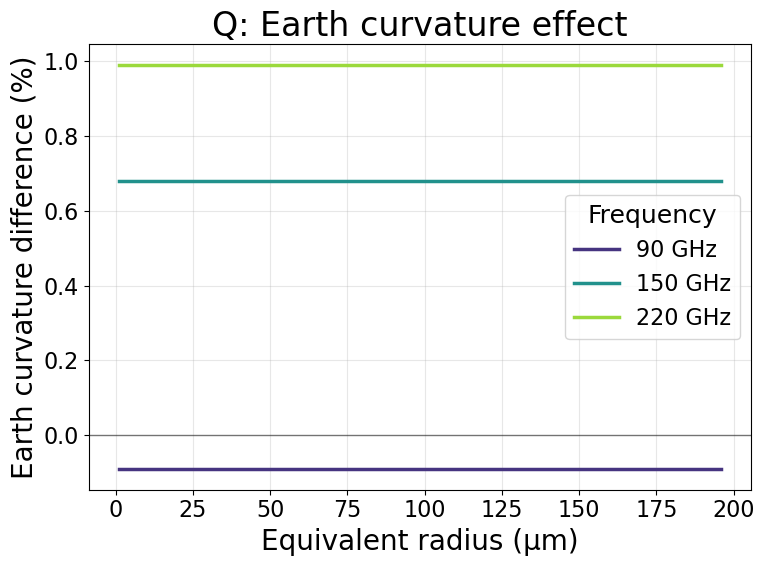

In [35]:
# Q: Compare the Earth-curvature effect on total Rayleigh scattering in percent for each frequency
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(frequency_ghz)))

for i, freq in enumerate(frequency_ghz):
    flat_q = Q_RJ_scattering_tot_flat_earth[i, :, 0]
    delta_percent_q = np.where(flat_q != 0, 100.0 * (Q_RJ_scattering_tot_earth_curv[i, :, 0] - flat_q) / flat_q, np.nan)
    ax.plot(
        r_eq * 1e6,
        delta_percent_q,
        color=colors[i],
        linewidth=2.5,
        label=f'{freq} GHz',
    )

ax.axhline(0, color='k', linewidth=1, alpha=0.5)
ax.set_xlabel('Equivalent radius (μm)')
ax.set_ylabel('Earth curvature difference (%)')
ax.set_title('Q: Earth curvature effect')
ax.grid(True, alpha=0.3)
ax.legend(title='Frequency')
fig.tight_layout()

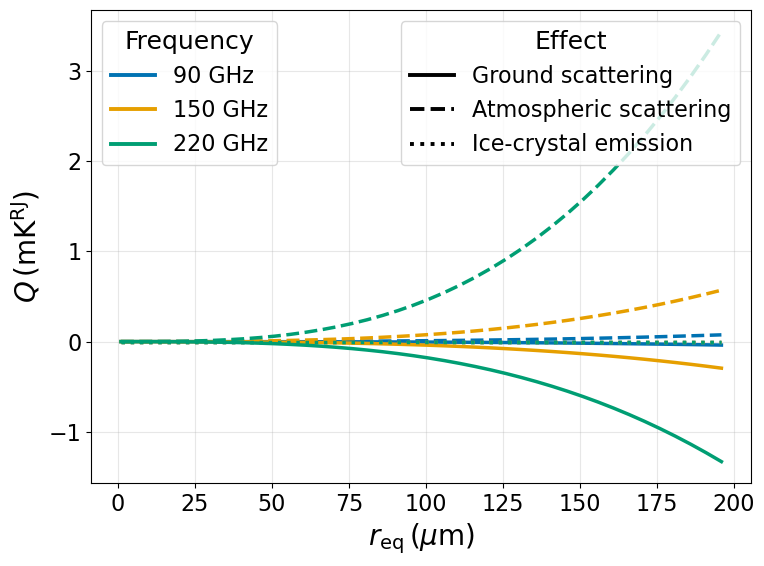

In [40]:
# Q: Unified comparison (color = frequency, line style = physical effect)
from matplotlib.lines import Line2D

y_log_scale_q = False  # Set to True for logarithmic y-axis

fig, ax = plt.subplots(figsize=(8, 6))

# High-contrast, colorblind-friendly palette (Okabe-Ito)
freq_colors = ['#0072B2', '#E69F00', '#009E73']  # blue, orange, green
if len(frequency_ghz) > len(freq_colors):
    freq_colors = list(plt.cm.tab10(np.linspace(0, 1, len(frequency_ghz))))

effects_q = [
    ('Ground scattering', Q_RJ_scattering_ground_earth_curv, '-'),
    ('Atmospheric scattering', Q_RJ_scattering_atmos_earth_curv, '--'),
    ('Ice-crystal emission', Q_RJ_emission, ':'),
]

for i, freq in enumerate(frequency_ghz):
    for effect_name, data, linestyle in effects_q:
        y_mk_q = data[i, :] * 1e3  # Convert K_RJ -> mK_RJ
        y_plot_q = np.where(y_mk_q > 0, y_mk_q, np.nan) if y_log_scale_q else y_mk_q
        ax.plot(
            r_eq * 1e6,
            y_plot_q,
            color=freq_colors[i],
            linestyle=linestyle,
            linewidth=2.5,
        )

if y_log_scale_q:
    ax.set_yscale('log')

ax.set_xlabel(r'$r_{\mathrm{eq}}\,(\mu\mathrm{m})$')
ax.set_ylabel(r'$Q\,(\mathrm{mK}^{\mathrm{RJ}})$')
#ax.set_title('Q: Comparing contributions')
ax.grid(True, alpha=0.3)

freq_handles = [
    Line2D([0], [0], color=freq_colors[i], lw=2.8, linestyle='-', label=f'{freq} GHz')
    for i, freq in enumerate(frequency_ghz)
]
effect_handles = [
    Line2D([0], [0], color='black', lw=2.8, linestyle=linestyle, label=effect_name)
    for effect_name, _, linestyle in effects_q
]

legend_freq = ax.legend(handles=freq_handles, title='Frequency', loc='upper left')
ax.add_artist(legend_freq)
ax.legend(handles=effect_handles, title='Effect', loc='upper right')

fig.tight_layout()

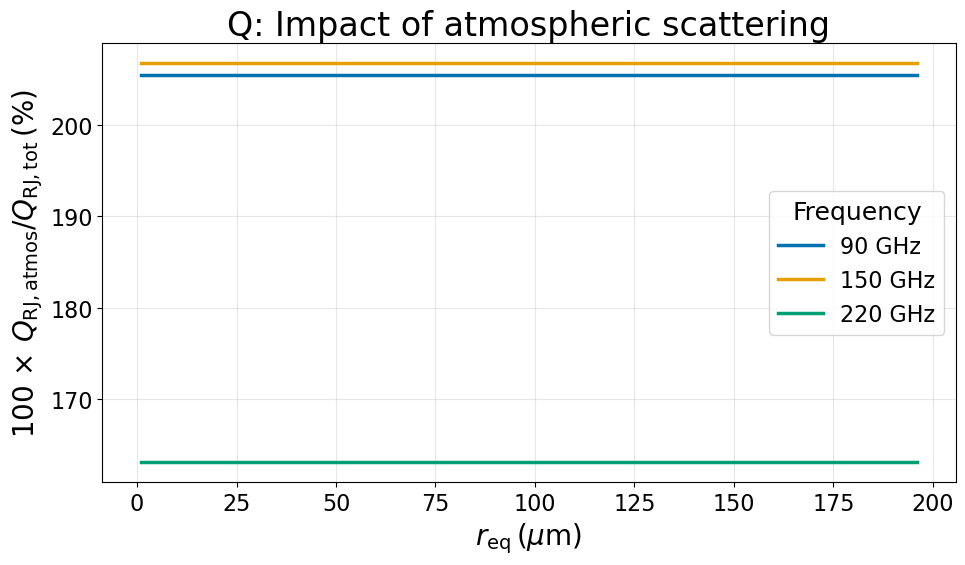

In [15]:
# Q: Percentage contribution of atmospheric scattering to total scattering (Earth-curvature case)
fig, ax = plt.subplots(figsize=(10, 6))

# Keep the same high-contrast frequency colors
freq_colors = ['#0072B2', '#E69F00', '#009E73']
if len(frequency_ghz) > len(freq_colors):
    freq_colors = list(plt.cm.tab10(np.linspace(0, 1, len(frequency_ghz))))

for i, freq in enumerate(frequency_ghz):
    total_q = Q_RJ_scattering_tot_earth_curv[i, :, 0]
    atmos_q = Q_RJ_scattering_atmos_earth_curv[i, :, 0]
    percent_q = np.where(total_q != 0, 100.0 * atmos_q / total_q, np.nan)

    ax.plot(
        r_eq * 1e6,
        percent_q,
        color=freq_colors[i],
        linewidth=2.5,
        label=f'{freq} GHz',
    )

ax.set_xlabel(r'$r_{\mathrm{eq}}\,(\mu\mathrm{m})$')
ax.set_ylabel(r'$100\,\times\,Q_{\mathrm{RJ,atmos}}/Q_{\mathrm{RJ,tot}}\,(\%)$')
ax.set_title('Q: Impact of atmospheric scattering')
ax.grid(True, alpha=0.3)
ax.legend(title='Frequency')
fig.tight_layout()

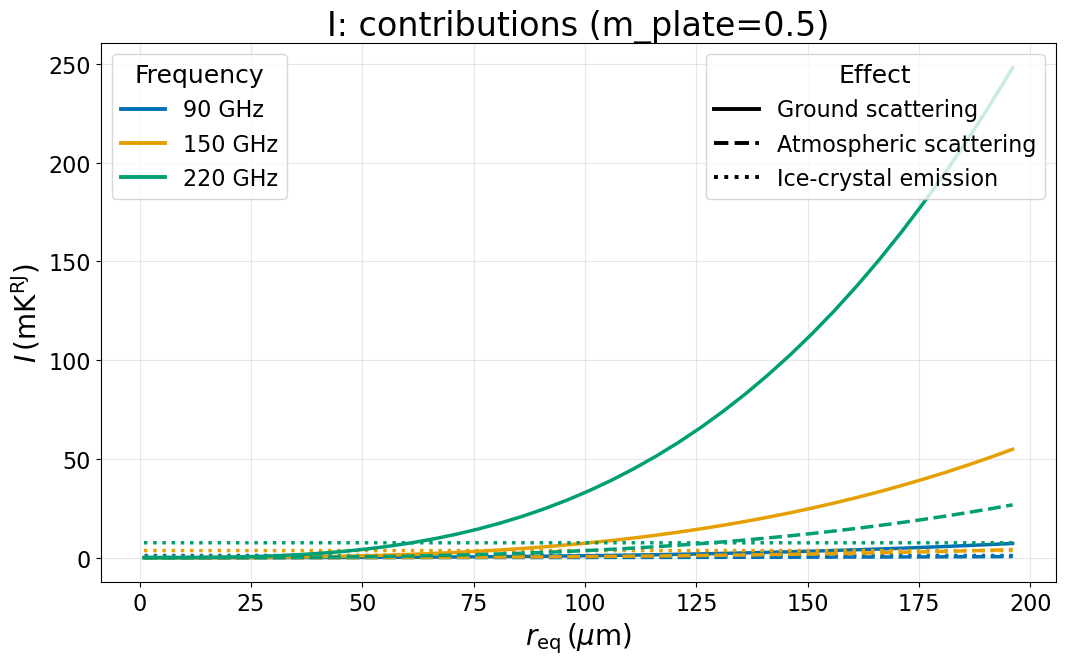

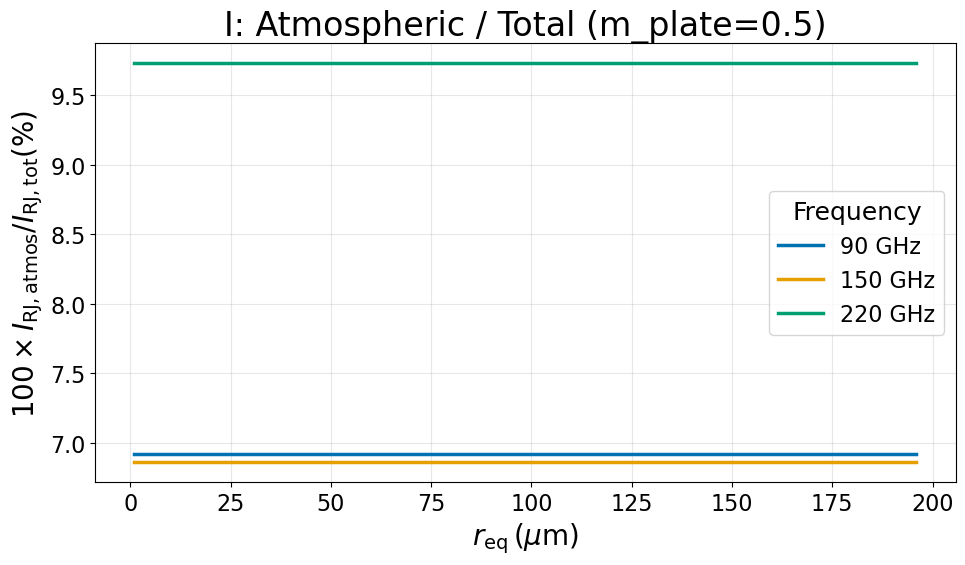

In [16]:
# --- Re-run the I-study with aspect ratio m_plate = 0.5 ---
m_plate = 0.5

# Compute with plate aspect ratio
I_RJ_scattering_tot_earth_curv_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_plate, stokes_param='I', consider_earth_curvature=True, consider_atmospheric_emission=True
)
I_RJ_scattering_tot_flat_earth_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_plate, stokes_param='I', consider_earth_curvature=False, consider_atmospheric_emission=True
)
I_RJ_scattering_ground_earth_curv_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_plate, stokes_param='I', consider_earth_curvature=True, consider_atmospheric_emission=False
)
I_RJ_scattering_ground_flat_earth_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_plate, stokes_param='I', consider_earth_curvature=False, consider_atmospheric_emission=False
)

I_RJ_scattering_atmos_earth_curv_plate = I_RJ_scattering_tot_earth_curv_plate - I_RJ_scattering_ground_earth_curv_plate
I_RJ_scattering_atmos_flat_earth_plate = I_RJ_scattering_tot_flat_earth_plate - I_RJ_scattering_ground_flat_earth_plate

I_RJ_emission_plate = compute_T_RJ_ice2(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq,
    aspect_ratio=m_plate, process='emission', stokes_param='I'
)
    

# 3) Unified plot: color = frequency, linestyle = effect (mK)
from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(11, 7))
effects = [
    ('Ground scattering', I_RJ_scattering_ground_earth_curv_plate, '-'),
    ('Atmospheric scattering', I_RJ_scattering_atmos_earth_curv_plate, '--'),
    ('Ice-crystal emission', I_RJ_emission_plate, ':'),
]
for i, freq in enumerate(frequency_ghz):
    for name, data, ls in effects:
        y = data[i, :]*1e3
        ax.plot(r_eq*1e6, y, color=freq_colors[i], linestyle=ls, linewidth=2.5)
ax.set_xlabel(r'$r_{\mathrm{eq}}\,(\mu\mathrm{m})$')
ax.set_ylabel(r'$I\,(\mathrm{mK}^{\mathrm{RJ}})$')
ax.set_title('I: contributions (m_plate=0.5)')
ax.grid(True, alpha=0.3)
freq_handles = [Line2D([0],[0], color=freq_colors[i], lw=2.8, label=f'{freq} GHz') for i, freq in enumerate(frequency_ghz)]
effect_handles = [Line2D([0],[0], color='black', lw=2.8, linestyle=ls, label=name) for name,_,ls in effects]
legend_freq = ax.legend(handles=freq_handles, title='Frequency', loc='upper left')
ax.add_artist(legend_freq)
ax.legend(handles=effect_handles, title='Effect', loc='upper right')
fig.tight_layout()

# 4) Atmospheric-to-total ratio (%)
fig, ax = plt.subplots(figsize=(10,6))
for i, freq in enumerate(frequency_ghz):
    total = I_RJ_scattering_tot_earth_curv_plate[i, :, 0]
    atmos = I_RJ_scattering_atmos_earth_curv_plate[i, :, 0]
    pct_atm = np.where(total!=0, 100.0*atmos/total, np.nan)
    ax.plot(r_eq*1e6, pct_atm, color=freq_colors[i], linewidth=2.5, label=f'{freq} GHz')
ax.set_xlabel(r'$r_{\mathrm{eq}}\,(\mu\mathrm{m})$')
ax.set_ylabel(r'$100\times I_{\mathrm{RJ,atmos}}/I_{\mathrm{RJ,tot}}(\%)$')
ax.set_title('I: Atmospheric / Total (m_plate=0.5)')
ax.grid(True, alpha=0.3)
ax.legend(title='Frequency')
fig.tight_layout()

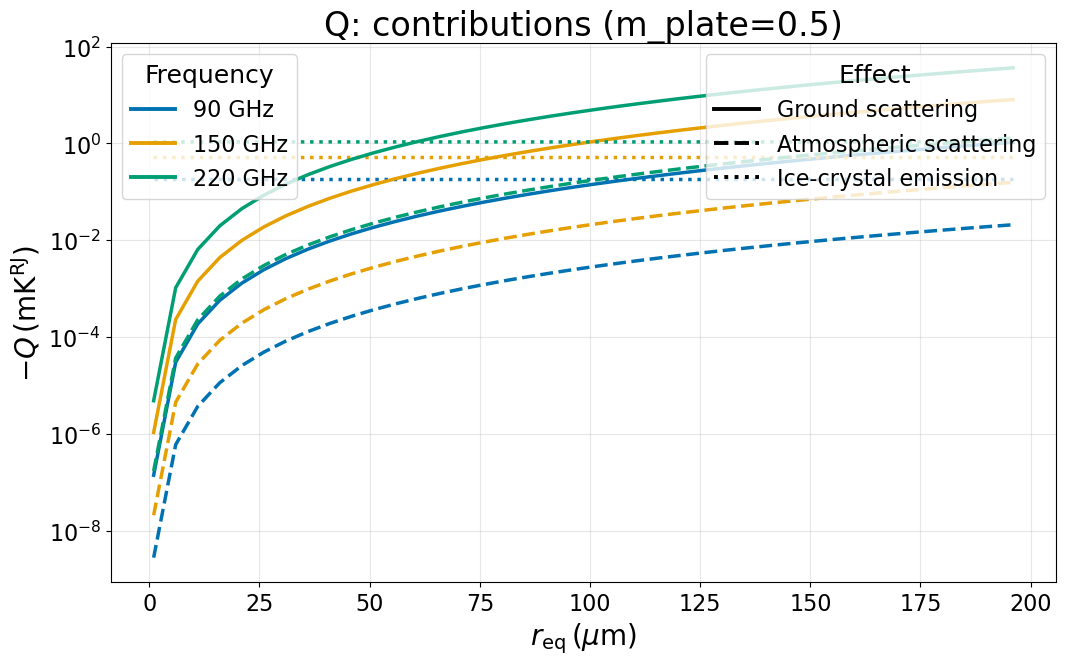

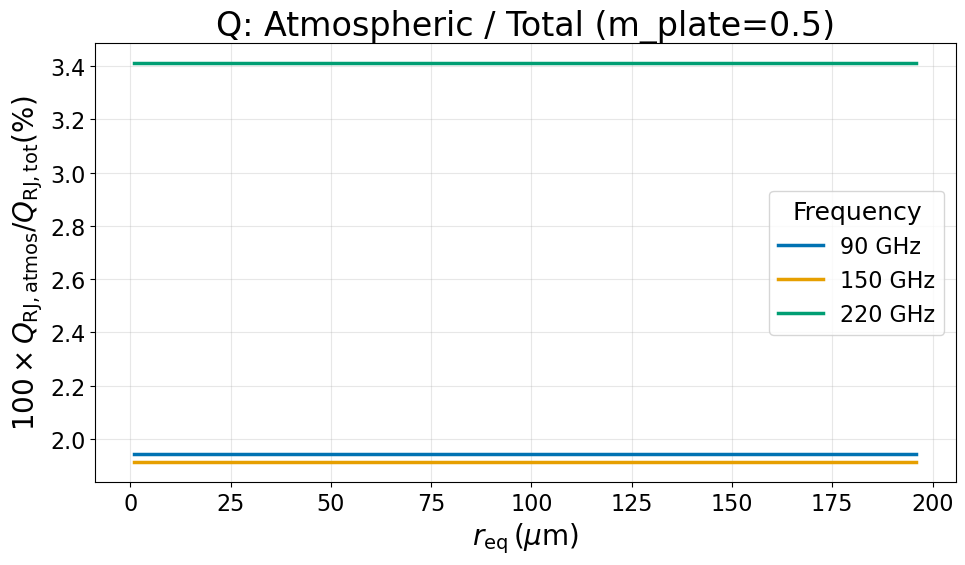

In [17]:
# --- Re-run the Q-study with aspect ratio m_plate = 0.5 ---
m_plate = 0.5

# Compute with plate aspect ratio for Stokes Q (variables named analogous to I but with _Q suffix)
Q_RJ_scattering_tot_earth_curv_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_plate, stokes_param='Q', consider_earth_curvature=True, consider_atmospheric_emission=True
)
Q_RJ_scattering_tot_flat_earth_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_plate, stokes_param='Q', consider_earth_curvature=False, consider_atmospheric_emission=True
)
Q_RJ_scattering_ground_earth_curv_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_plate, stokes_param='Q', consider_earth_curvature=True, consider_atmospheric_emission=False
)
Q_RJ_scattering_ground_flat_earth_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_plate, stokes_param='Q', consider_earth_curvature=False, consider_atmospheric_emission=False
)

Q_RJ_scattering_atmos_earth_curv_plate = Q_RJ_scattering_tot_earth_curv_plate - Q_RJ_scattering_ground_earth_curv_plate
Q_RJ_scattering_atmos_flat_earth_plate = Q_RJ_scattering_tot_flat_earth_plate - Q_RJ_scattering_ground_flat_earth_plate

Q_RJ_emission_plate = compute_T_RJ_ice2(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq,
    aspect_ratio=m_plate, process='emission', stokes_param='Q'
)


# 3) Unified plot: color = frequency, linestyle = effect (mK)
from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(11, 7))
effects = [
    ('Ground scattering', Q_RJ_scattering_ground_earth_curv_plate, '-'),
    ('Atmospheric scattering', Q_RJ_scattering_atmos_earth_curv_plate, '--'),
    ('Ice-crystal emission', Q_RJ_emission_plate, ':'),
]
for i, freq in enumerate(frequency_ghz):
    for name, data, ls in effects:
        y = - data[i, :]*1e3
        ax.plot(r_eq*1e6, y, color=freq_colors[i], linestyle=ls, linewidth=2.5)
ax.set_xlabel(r'$r_{\mathrm{eq}}\,(\mu\mathrm{m})$')
ax.set_ylabel(r'$- Q\,(\mathrm{mK}^{\mathrm{RJ}})$')
ax.set_title('Q: contributions (m_plate=0.5)')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
freq_handles = [Line2D([0],[0], color=freq_colors[i], lw=2.8, label=f'{freq} GHz') for i, freq in enumerate(frequency_ghz)]
effect_handles = [Line2D([0],[0], color='black', lw=2.8, linestyle=ls, label=name) for name,_,ls in effects]
legend_freq = ax.legend(handles=freq_handles, title='Frequency', loc='upper left')
ax.add_artist(legend_freq)
ax.legend(handles=effect_handles, title='Effect', loc='upper right')
fig.tight_layout()

# 4) Atmospheric-to-total ratio (%)
fig, ax = plt.subplots(figsize=(10,6))
for i, freq in enumerate(frequency_ghz):
    total = Q_RJ_scattering_tot_earth_curv_plate[i, :, 0]
    atmos = Q_RJ_scattering_atmos_earth_curv_plate[i, :, 0]
    pct_atm = np.where(total!=0, 100.0*atmos/total, np.nan)
    ax.plot(r_eq*1e6, pct_atm, color=freq_colors[i], linewidth=2.5, label=f'{freq} GHz')
ax.set_xlabel(r'$r_{\mathrm{eq}}\,(\mu\mathrm{m})$')
ax.set_ylabel(r'$100\times Q_{\mathrm{RJ,atmos}}/Q_{\mathrm{RJ,tot}}(\%)$')
ax.set_title('Q: Atmospheric / Total (m_plate=0.5)')
ax.grid(True, alpha=0.3)
ax.legend(title='Frequency')
fig.tight_layout()

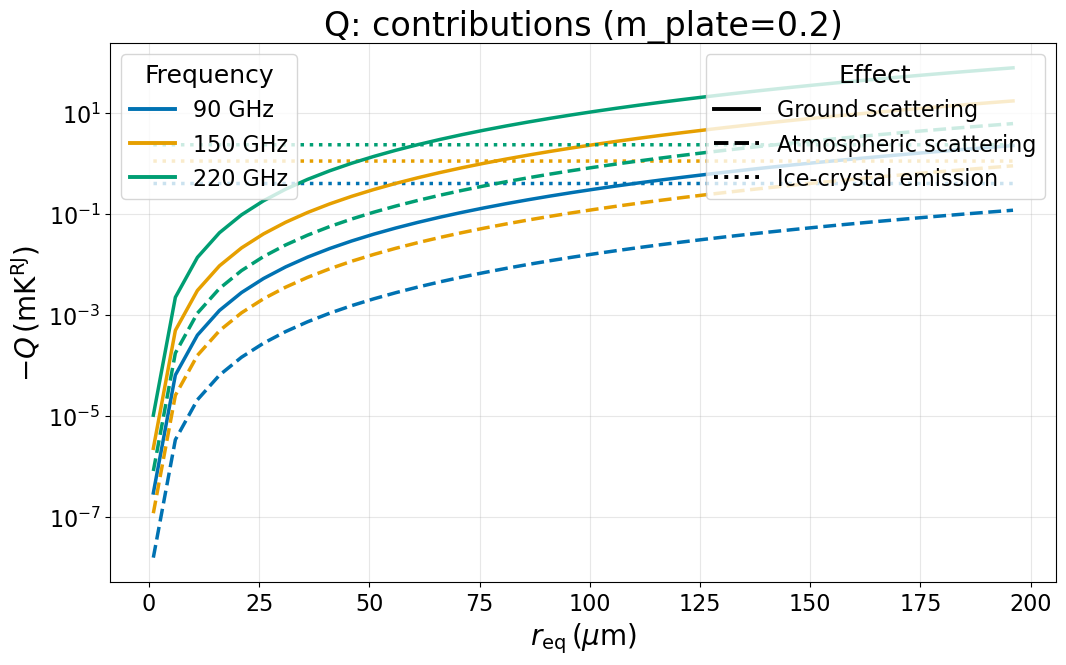

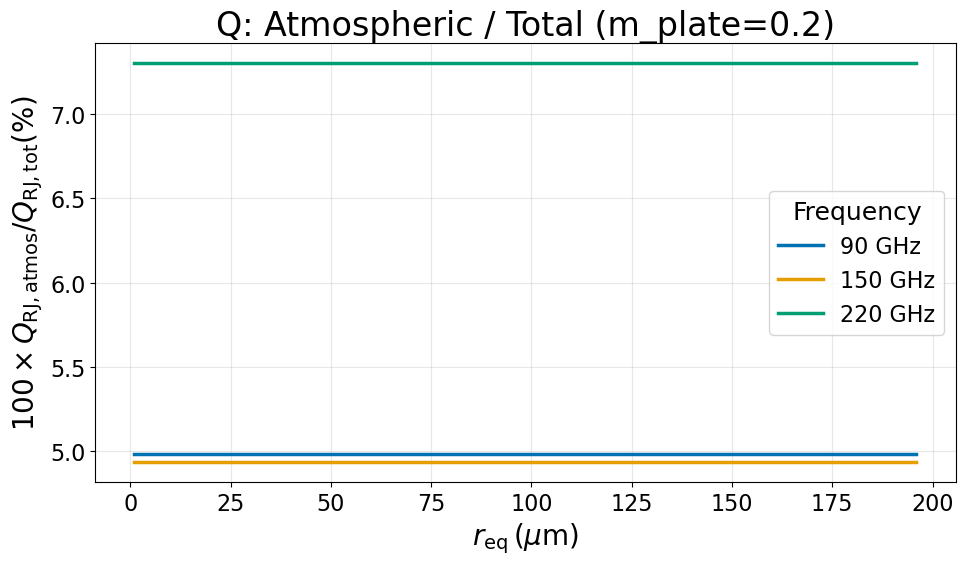

In [18]:
# --- Re-run the Q-study with aspect ratio m_plate = 0.2 ---
m_plate = 0.2

# Compute with plate aspect ratio for Stokes Q (variables named analogous to I but with _Q suffix)
Q_RJ_scattering_tot_earth_curv_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_plate, stokes_param='Q', consider_earth_curvature=True, consider_atmospheric_emission=True
)
Q_RJ_scattering_tot_flat_earth_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_plate, stokes_param='Q', consider_earth_curvature=False, consider_atmospheric_emission=True
)
Q_RJ_scattering_ground_earth_curv_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_plate, stokes_param='Q', consider_earth_curvature=True, consider_atmospheric_emission=False
)
Q_RJ_scattering_ground_flat_earth_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_plate, stokes_param='Q', consider_earth_curvature=False, consider_atmospheric_emission=False
)

Q_RJ_scattering_atmos_earth_curv_plate = Q_RJ_scattering_tot_earth_curv_plate - Q_RJ_scattering_ground_earth_curv_plate
Q_RJ_scattering_atmos_flat_earth_plate = Q_RJ_scattering_tot_flat_earth_plate - Q_RJ_scattering_ground_flat_earth_plate

Q_RJ_emission_plate = compute_T_RJ_ice2(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq,
    aspect_ratio=m_plate, process='emission', stokes_param='Q'
)


# 3) Unified plot: color = frequency, linestyle = effect (mK)
from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(11, 7))
effects = [
    ('Ground scattering', Q_RJ_scattering_ground_earth_curv_plate, '-'),
    ('Atmospheric scattering', Q_RJ_scattering_atmos_earth_curv_plate, '--'),
    ('Ice-crystal emission', Q_RJ_emission_plate, ':'),
]
for i, freq in enumerate(frequency_ghz):
    for name, data, ls in effects:
        y = - data[i, :]*1e3
        ax.plot(r_eq*1e6, y, color=freq_colors[i], linestyle=ls, linewidth=2.5)
ax.set_xlabel(r'$r_{\mathrm{eq}}\,(\mu\mathrm{m})$')
ax.set_ylabel(r'$- Q\,(\mathrm{mK}^{\mathrm{RJ}})$')
ax.set_title('Q: contributions (m_plate=0.2)')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
freq_handles = [Line2D([0],[0], color=freq_colors[i], lw=2.8, label=f'{freq} GHz') for i, freq in enumerate(frequency_ghz)]
effect_handles = [Line2D([0],[0], color='black', lw=2.8, linestyle=ls, label=name) for name,_,ls in effects]
legend_freq = ax.legend(handles=freq_handles, title='Frequency', loc='upper left')
ax.add_artist(legend_freq)
ax.legend(handles=effect_handles, title='Effect', loc='upper right')
fig.tight_layout()

# 4) Atmospheric-to-total ratio (%)
fig, ax = plt.subplots(figsize=(10,6))
for i, freq in enumerate(frequency_ghz):
    total = Q_RJ_scattering_tot_earth_curv_plate[i, :, 0]
    atmos = Q_RJ_scattering_atmos_earth_curv_plate[i, :, 0]
    pct_atm = np.where(total!=0, 100.0*atmos/total, np.nan)
    ax.plot(r_eq*1e6, pct_atm, color=freq_colors[i], linewidth=2.5, label=f'{freq} GHz')
ax.set_xlabel(r'$r_{\mathrm{eq}}\,(\mu\mathrm{m})$')
ax.set_ylabel(r'$100\times Q_{\mathrm{RJ,atmos}}/Q_{\mathrm{RJ,tot}}(\%)$')
ax.set_title('Q: Atmospheric / Total (m_plate=0.2)')
ax.grid(True, alpha=0.3)
ax.legend(title='Frequency')
fig.tight_layout()

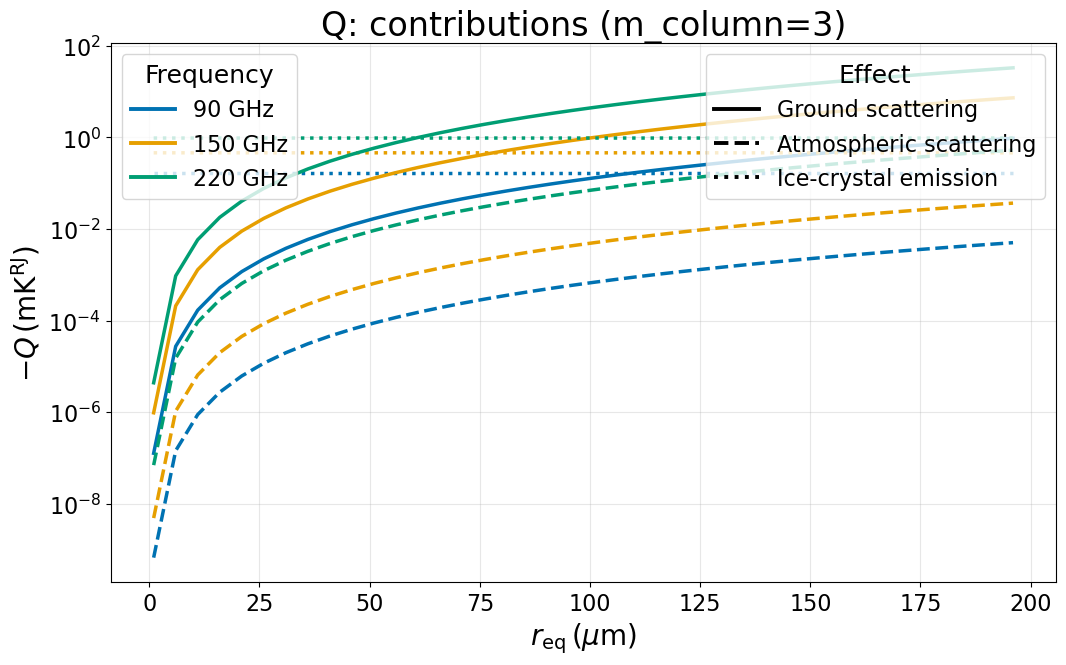

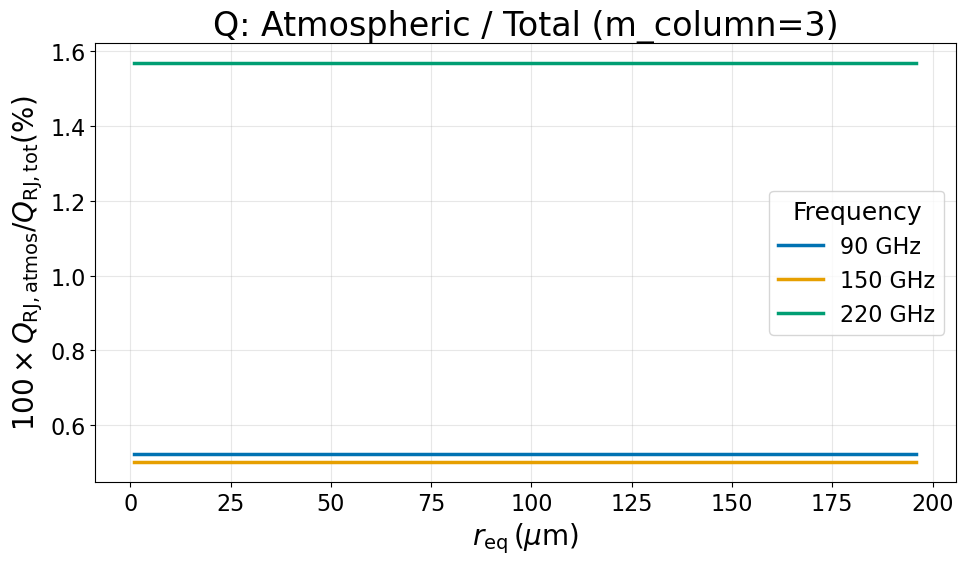

In [19]:
# --- Re-run the Q-study with aspect ratio m_column = 0.5 ---
m_column = 3

# Compute with plate aspect ratio for Stokes Q (variables named analogous to I but with _Q suffix)
Q_RJ_scattering_tot_earth_curv_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_column, stokes_param='Q', consider_earth_curvature=True, consider_atmospheric_emission=True
)
Q_RJ_scattering_tot_flat_earth_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_column, stokes_param='Q', consider_earth_curvature=False, consider_atmospheric_emission=True
)
Q_RJ_scattering_ground_earth_curv_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_column, stokes_param='Q', consider_earth_curvature=True, consider_atmospheric_emission=False
)
Q_RJ_scattering_ground_flat_earth_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_column, stokes_param='Q', consider_earth_curvature=False, consider_atmospheric_emission=False
)

Q_RJ_scattering_atmos_earth_curv_plate = Q_RJ_scattering_tot_earth_curv_plate - Q_RJ_scattering_ground_earth_curv_plate
Q_RJ_scattering_atmos_flat_earth_plate = Q_RJ_scattering_tot_flat_earth_plate - Q_RJ_scattering_ground_flat_earth_plate

Q_RJ_emission_plate = compute_T_RJ_ice2(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq,
    aspect_ratio=m_column, process='emission', stokes_param='Q'
)


# 3) Unified plot: color = frequency, linestyle = effect (mK)
from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(11, 7))
effects = [
    ('Ground scattering', Q_RJ_scattering_ground_earth_curv_plate, '-'),
    ('Atmospheric scattering', Q_RJ_scattering_atmos_earth_curv_plate, '--'),
    ('Ice-crystal emission', Q_RJ_emission_plate, ':'),
]
for i, freq in enumerate(frequency_ghz):
    for name, data, ls in effects:
        y = - data[i, :]*1e3
        ax.plot(r_eq*1e6, y, color=freq_colors[i], linestyle=ls, linewidth=2.5)
ax.set_xlabel(r'$r_{\mathrm{eq}}\,(\mu\mathrm{m})$')
ax.set_ylabel(r'$- Q\,(\mathrm{mK}^{\mathrm{RJ}})$')
ax.set_title('Q: contributions (m_column=3)')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
freq_handles = [Line2D([0],[0], color=freq_colors[i], lw=2.8, label=f'{freq} GHz') for i, freq in enumerate(frequency_ghz)]
effect_handles = [Line2D([0],[0], color='black', lw=2.8, linestyle=ls, label=name) for name,_,ls in effects]
legend_freq = ax.legend(handles=freq_handles, title='Frequency', loc='upper left')
ax.add_artist(legend_freq)
ax.legend(handles=effect_handles, title='Effect', loc='upper right')
fig.tight_layout()

# 4) Atmospheric-to-total ratio (%)
fig, ax = plt.subplots(figsize=(10,6))
for i, freq in enumerate(frequency_ghz):
    total = Q_RJ_scattering_tot_earth_curv_plate[i, :, 0]
    atmos = Q_RJ_scattering_atmos_earth_curv_plate[i, :, 0]
    pct_atm = np.where(total!=0, 100.0*atmos/total, np.nan)
    ax.plot(r_eq*1e6, pct_atm, color=freq_colors[i], linewidth=2.5, label=f'{freq} GHz')
ax.set_xlabel(r'$r_{\mathrm{eq}}\,(\mu\mathrm{m})$')
ax.set_ylabel(r'$100\times Q_{\mathrm{RJ,atmos}}/Q_{\mathrm{RJ,tot}}(\%)$')
ax.set_title('Q: Atmospheric / Total (m_column=3)')
ax.grid(True, alpha=0.3)
ax.legend(title='Frequency')
fig.tight_layout()

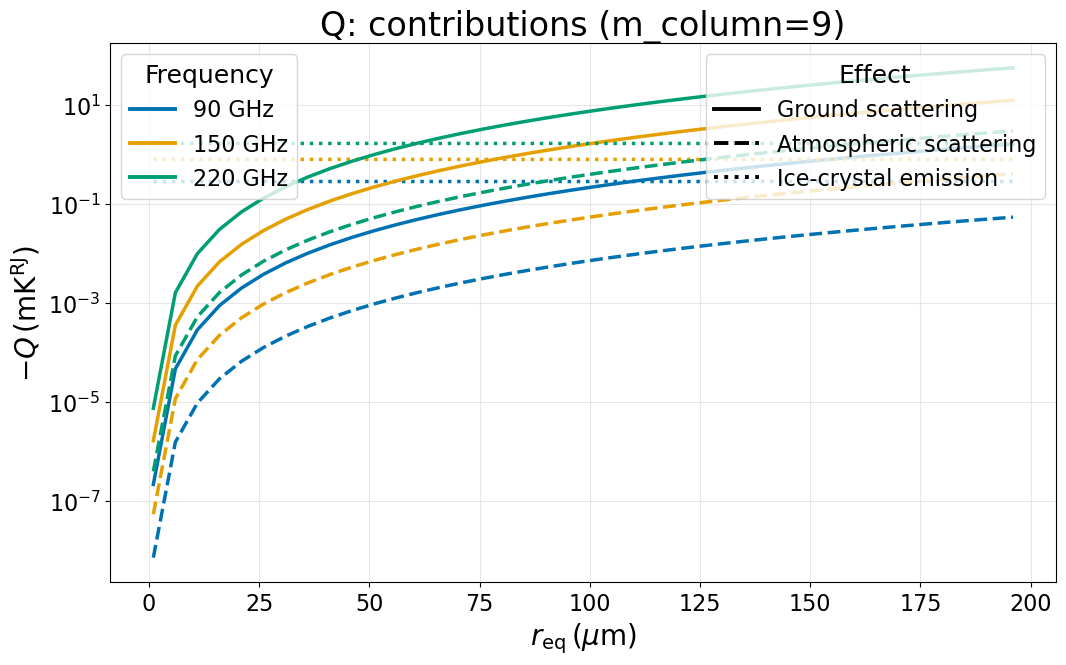

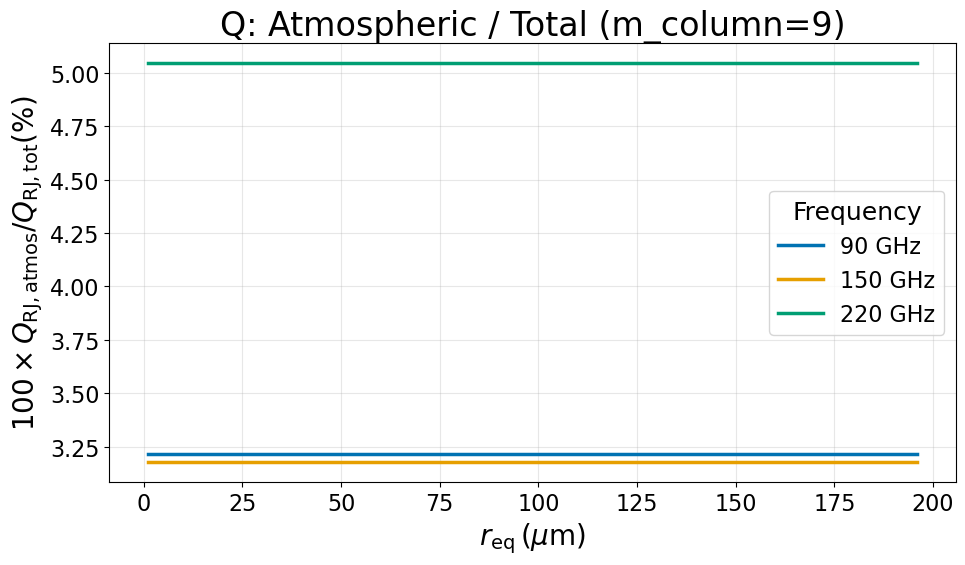

In [20]:
# --- Re-run the Q-study with aspect ratio m_column = 0.5 ---
m_column = 9

# Compute with plate aspect ratio for Stokes Q (variables named analogous to I but with _Q suffix)
Q_RJ_scattering_tot_earth_curv_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_column, stokes_param='Q', consider_earth_curvature=True, consider_atmospheric_emission=True
)
Q_RJ_scattering_tot_flat_earth_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_column, stokes_param='Q', consider_earth_curvature=False, consider_atmospheric_emission=True
)
Q_RJ_scattering_ground_earth_curv_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_column, stokes_param='Q', consider_earth_curvature=True, consider_atmospheric_emission=False
)
Q_RJ_scattering_ground_flat_earth_plate = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m_column, stokes_param='Q', consider_earth_curvature=False, consider_atmospheric_emission=False
)

Q_RJ_scattering_atmos_earth_curv_plate = Q_RJ_scattering_tot_earth_curv_plate - Q_RJ_scattering_ground_earth_curv_plate
Q_RJ_scattering_atmos_flat_earth_plate = Q_RJ_scattering_tot_flat_earth_plate - Q_RJ_scattering_ground_flat_earth_plate

Q_RJ_emission_plate = compute_T_RJ_ice2(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq,
    aspect_ratio=m_column, process='emission', stokes_param='Q'
)


# 3) Unified plot: color = frequency, linestyle = effect (mK)
from matplotlib.lines import Line2D
fig, ax = plt.subplots(figsize=(11, 7))
effects = [
    ('Ground scattering', Q_RJ_scattering_ground_earth_curv_plate, '-'),
    ('Atmospheric scattering', Q_RJ_scattering_atmos_earth_curv_plate, '--'),
    ('Ice-crystal emission', Q_RJ_emission_plate, ':'),
]
for i, freq in enumerate(frequency_ghz):
    for name, data, ls in effects:
        y = - data[i, :]*1e3
        ax.plot(r_eq*1e6, y, color=freq_colors[i], linestyle=ls, linewidth=2.5)
ax.set_xlabel(r'$r_{\mathrm{eq}}\,(\mu\mathrm{m})$')
ax.set_ylabel(r'$- Q\,(\mathrm{mK}^{\mathrm{RJ}})$')
ax.set_title('Q: contributions (m_column=9)')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
freq_handles = [Line2D([0],[0], color=freq_colors[i], lw=2.8, label=f'{freq} GHz') for i, freq in enumerate(frequency_ghz)]
effect_handles = [Line2D([0],[0], color='black', lw=2.8, linestyle=ls, label=name) for name,_,ls in effects]
legend_freq = ax.legend(handles=freq_handles, title='Frequency', loc='upper left')
ax.add_artist(legend_freq)
ax.legend(handles=effect_handles, title='Effect', loc='upper right')
fig.tight_layout()

# 4) Atmospheric-to-total ratio (%)
fig, ax = plt.subplots(figsize=(10,6))
for i, freq in enumerate(frequency_ghz):
    total = Q_RJ_scattering_tot_earth_curv_plate[i, :, 0]
    atmos = Q_RJ_scattering_atmos_earth_curv_plate[i, :, 0]
    pct_atm = np.where(total!=0, 100.0*atmos/total, np.nan)
    ax.plot(r_eq*1e6, pct_atm, color=freq_colors[i], linewidth=2.5, label=f'{freq} GHz')
ax.set_xlabel(r'$r_{\mathrm{eq}}\,(\mu\mathrm{m})$')
ax.set_ylabel(r'$100\times Q_{\mathrm{RJ,atmos}}/Q_{\mathrm{RJ,tot}}(\%)$')
ax.set_title('Q: Atmospheric / Total (m_column=9)')
ax.grid(True, alpha=0.3)
ax.legend(title='Frequency')
fig.tight_layout()

In [41]:
altitudes = np.linspace(1, 10000, 500) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en hPa
dz = np.diff(altitudes) # Shape: (len(altitudes)-1,)
frequency_ghz = np.array([90, 150, 220]) # GHz
frequency = frequency_ghz * 1e9 # Hz

pi = constants.pi 
c = constants.c
rho_ice = 917 #kg/m^3

elevation = 45 #degrees
IWP = 1e-3 #kg/m2

layer_bottom = 6000  # Bottom of the ice cloud layer in meters (example)
layer_top = 7000     # Top of the ice cloud layer in meters (example)
cloud_thickness = layer_top - layer_bottom # Thickness of the ice cloud layer in meters

r_eq = np.array([30e-6]) # equivalet radius in meters

# 3. Calculate d(IWP)/dz (which is the Ice Water Content)
# For a uniform cloud, it is just Total IWP / thickness
IWC_constant = IWP / cloud_thickness # kg/m^3

# Create the IWC profile (0 everywhere except in the cloud)
IWC_profile = np.where((altitudes >= layer_bottom) & (altitudes <= layer_top), IWC_constant, 0.0)
# Shape of IWC_profile is (Nz,)

# 4. Compute Volume of the crystals for all radii
V = (4.0 / 3.0) * np.pi * r_eq**3 # Shape: (Na,)

# 5. Compute the ice density n(z, r_eq) using Broadcasting
# We use [:, None] to make IWC a column (Nz, 1) 
# We use [None, :] to make V a row (1, Na)
# The result is a 2D grid of shape (Nz, Na)
n = IWC_profile[:, None] / (rho_ice * V[None, :])

#We could normalize PWV to 1 mm

m = np.geomspace(0.05, 20.0, 200)

In [42]:
I_RJ_scattering_tot_earth_curv = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m, stokes_param='I', consider_earth_curvature=True, consider_atmospheric_emission=True
)

I_RJ_scattering_ground_earth_curv = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m, stokes_param='I', consider_earth_curvature=True, consider_atmospheric_emission=False
)


I_RJ_scattering_atmos_earth_curv = I_RJ_scattering_tot_earth_curv - I_RJ_scattering_ground_earth_curv


I_RJ_emission = compute_T_RJ_ice2(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq,
    aspect_ratio=m, process='emission', stokes_param='I'
)

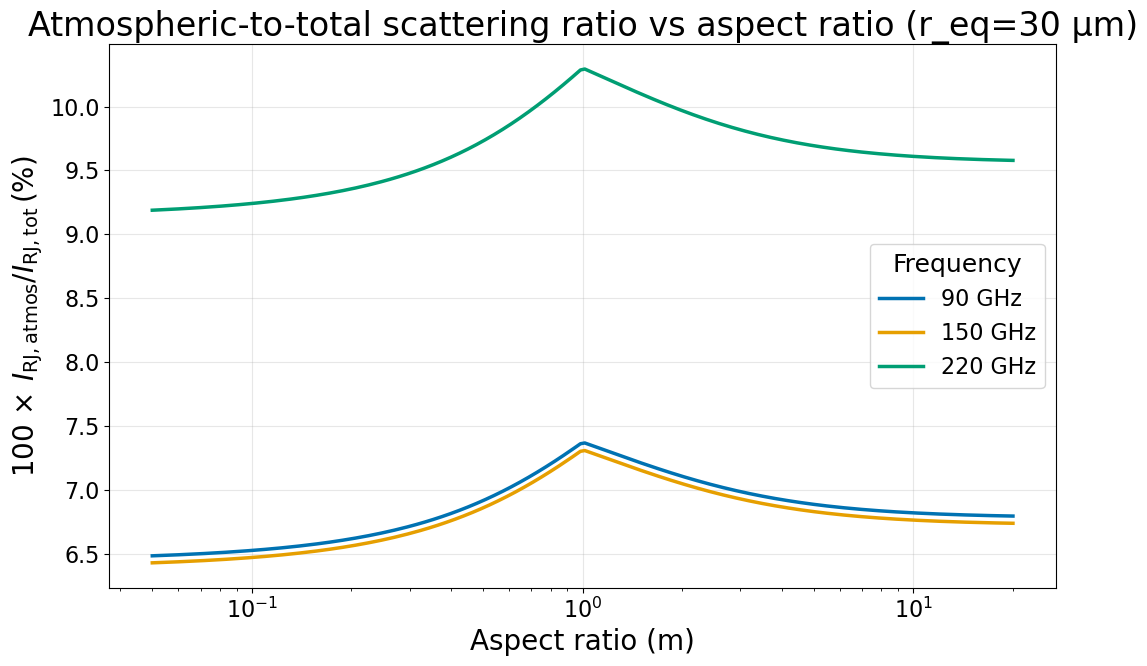

In [8]:
# Plot percentage atmospheric contribution vs aspect ratio (m) for each frequency
fig, ax = plt.subplots(figsize=(11, 7))

# High-contrast, colorblind-friendly palette
freq_colors = ['#0072B2', '#E69F00', '#009E73']
if len(frequency_ghz) > len(freq_colors):
    freq_colors = list(plt.cm.tab10(np.linspace(0, 1, len(frequency_ghz))))

for i, freq in enumerate(frequency_ghz):
    total = I_RJ_scattering_tot_earth_curv[i, 0, :]
    atmos = I_RJ_scattering_atmos_earth_curv[i, 0, :]
    pct_atm = np.where(total != 0, 100.0 * atmos / total, np.nan)
    
    ax.plot(m, pct_atm, color=freq_colors[i], linewidth=2.5, label=f'{freq} GHz')

ax.set_xlabel('Aspect ratio (m)')
ax.set_ylabel(r'$100\,\times\,I_{\mathrm{RJ,atmos}}/I_{\mathrm{RJ,tot}}\,(\%)$')
ax.set_title('Atmospheric-to-total scattering ratio vs aspect ratio (r_eq=30 μm)')
ax.grid(True, alpha=0.3)
ax.legend(title='Frequency')
ax.set_xscale('log')
fig.tight_layout()

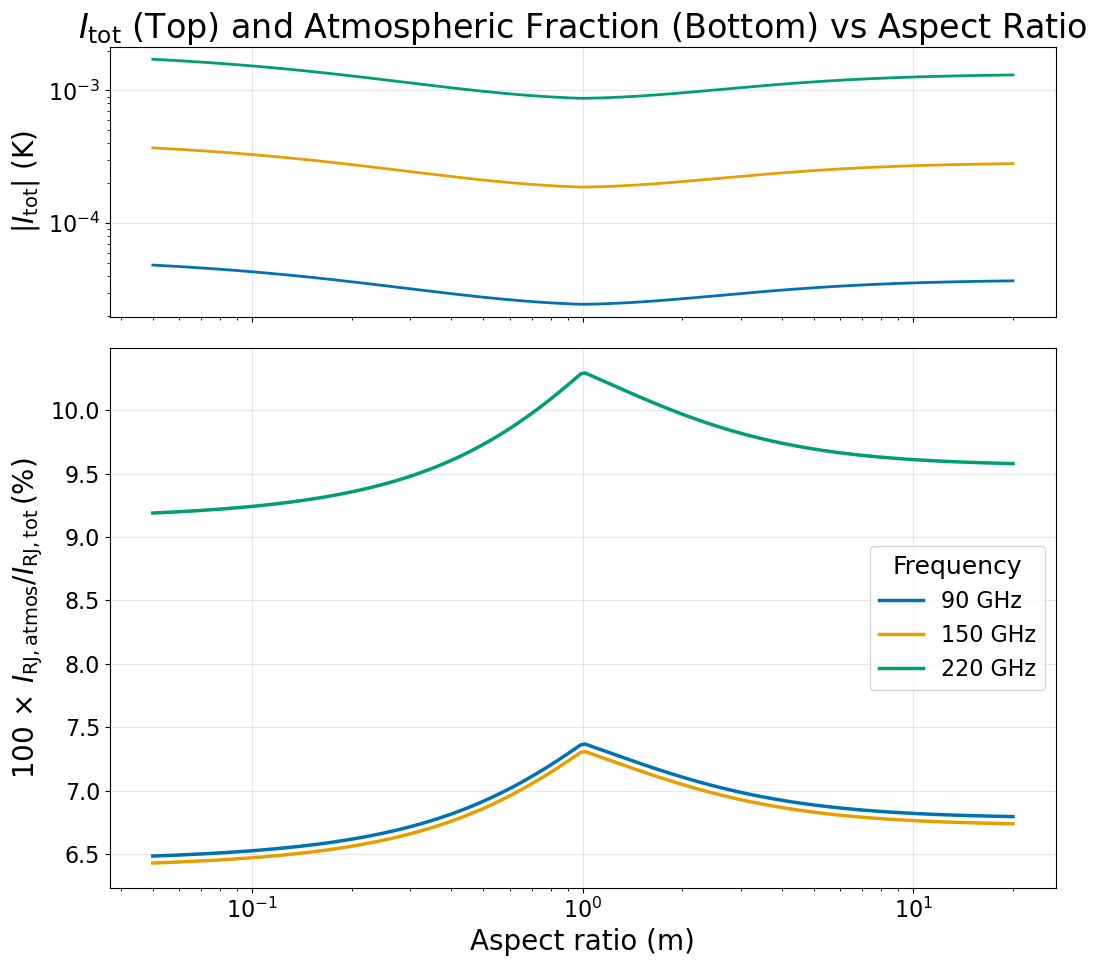

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Create two stacked subplots sharing the X-axis
# height_ratios=[1, 2] makes the bottom percentage graph twice as tall as the top reference graph
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 10), sharex=True, gridspec_kw={'height_ratios': [1, 2]})

# High-contrast, colorblind-friendly palette
freq_colors = ['#0072B2', '#E69F00', '#009E73']
if len(frequency_ghz) > len(freq_colors):
    freq_colors = list(plt.cm.tab10(np.linspace(0, 1, len(frequency_ghz))))

for i, freq in enumerate(frequency_ghz):
    total = I_RJ_scattering_tot_earth_curv[i, 0, :]
    atmos = I_RJ_scattering_atmos_earth_curv[i, 0, :]
    pct_atm = np.where(total != 0, 100.0 * atmos / total, np.nan)
    
    # --- Top Panel: Absolute Total Signal (I_tot) ---
    # We use np.abs() just to be safe with log scales, though I_tot should be strictly positive
    ax_top.plot(
        m, np.abs(total), 
        color=freq_colors[i], 
        linewidth=2.0
    )
    
    # --- Bottom Panel: Fractional Contribution (%) ---
    ax_bot.plot(
        m, pct_atm, 
        color=freq_colors[i], 
        linewidth=2.5, 
        label=f'{freq} GHz'
    )

# ==========================================
# FORMATTING: Top Panel (Absolute Signal)
# ==========================================
ax_top.set_ylabel(r'$|I_{\mathrm{tot}}|$ (K)')
ax_top.set_title(r'$I_{\mathrm{tot}}$ (Top) and Atmospheric Fraction (Bottom) vs Aspect Ratio')
ax_top.set_yscale('log')  # Intensity varies wildly with particle shape, log scale is highly recommended
ax_top.grid(True, alpha=0.3)

# ==========================================
# FORMATTING: Bottom Panel (Percentage)
# ==========================================
ax_bot.set_xlabel('Aspect ratio (m)')
ax_bot.set_ylabel(r'$100\,\times\,I_{\mathrm{RJ,atmos}}/I_{\mathrm{RJ,tot}}\,(\%)$')
ax_bot.set_xscale('log')  # Keep your log scale for the aspect ratio (applies to both shared axes)
ax_bot.grid(True, alpha=0.3)
ax_bot.legend(title='Frequency')

fig.tight_layout()
plt.show()

In [45]:
Q_RJ_scattering_tot_earth_curv = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m, stokes_param='Q', consider_earth_curvature=True, consider_atmospheric_emission=True
)

Q_RJ_scattering_ground_earth_curv = compute_T_RJ_ice_CLASS1(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n,
    r_eq, aspect_ratio=m, stokes_param='Q', consider_earth_curvature=True, consider_atmospheric_emission=False
)


Q_RJ_scattering_atmos_earth_curv = Q_RJ_scattering_tot_earth_curv - Q_RJ_scattering_ground_earth_curv


Q_RJ_emission = compute_T_RJ_ice2(
    frequency, altitudes, Temperature, Pressure, P_water, elevation, n, r_eq,
    aspect_ratio=m, process='emission', stokes_param='Q'
)

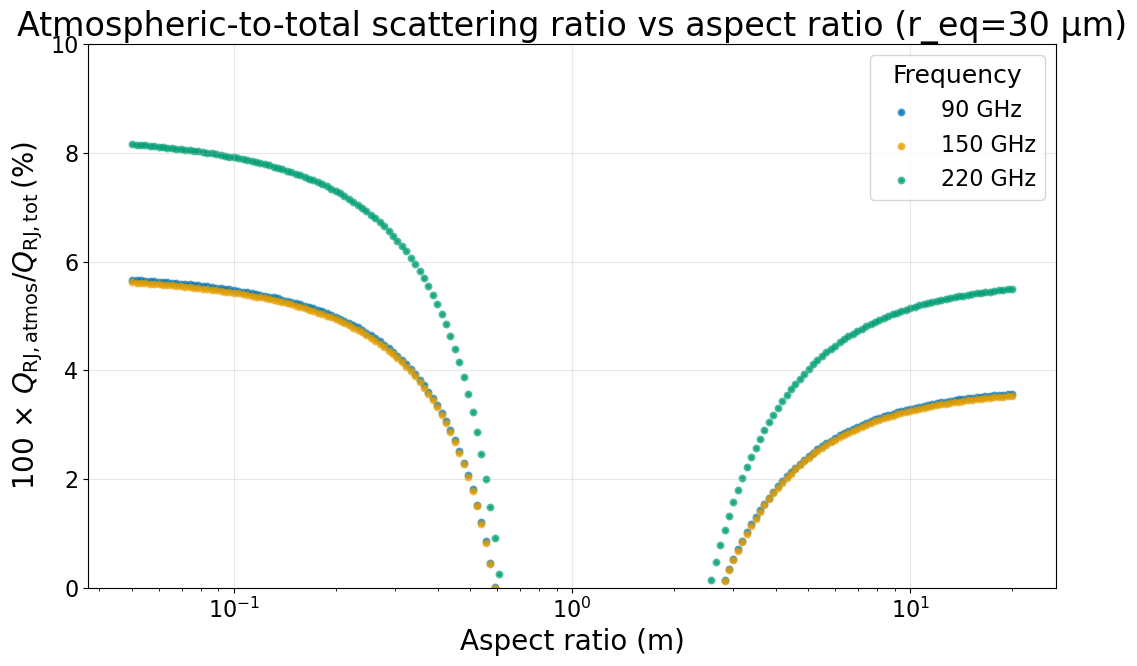

In [19]:
# Plot percentage atmospheric contribution vs aspect ratio (m) for each frequency
fig, ax = plt.subplots(figsize=(11, 7))

# High-contrast, colorblind-friendly palette
freq_colors = ['#0072B2', '#E69F00', '#009E73']
if len(frequency_ghz) > len(freq_colors):
    freq_colors = list(plt.cm.tab10(np.linspace(0, 1, len(frequency_ghz))))

for i, freq in enumerate(frequency_ghz):
    total = Q_RJ_scattering_tot_earth_curv[i, 0, :]
    atmos = Q_RJ_scattering_atmos_earth_curv[i, 0, :]
    pct_atm = np.where(total != 0, 100.0 * atmos / total, np.nan)
    
    ax.scatter(m, pct_atm, color=freq_colors[i], linewidth=2.5, label=f'{freq} GHz', s=10, alpha=0.7)

ax.set_xlabel('Aspect ratio (m)')
ax.set_ylabel(r'$100\,\times\,Q_{\mathrm{RJ,atmos}}/Q_{\mathrm{RJ,tot}}\,(\%)$')
ax.set_title('Atmospheric-to-total scattering ratio vs aspect ratio (r_eq=30 μm)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 10)
ax.legend(title='Frequency')
ax.set_xscale('log')
fig.tight_layout()

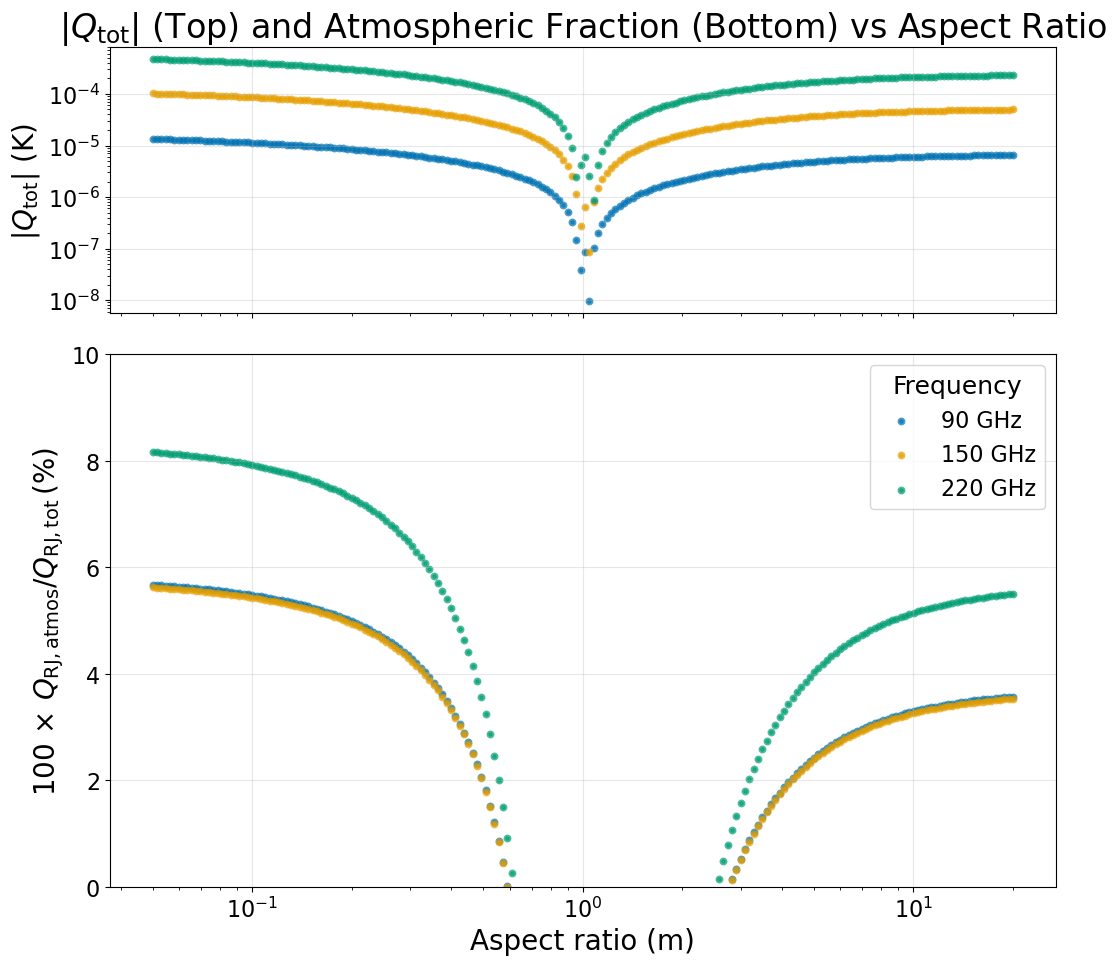

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Create two stacked subplots sharing the X-axis
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 10), sharex=True, gridspec_kw={'height_ratios': [1, 2]})

# High-contrast, colorblind-friendly palette
freq_colors = ['#0072B2', '#E69F00', '#009E73']
if len(frequency_ghz) > len(freq_colors):
    freq_colors = list(plt.cm.tab10(np.linspace(0, 1, len(frequency_ghz))))

for i, freq in enumerate(frequency_ghz):
    total = Q_RJ_scattering_tot_earth_curv[i, 0, :]
    atmos = Q_RJ_scattering_atmos_earth_curv[i, 0, :]
    pct_atm = np.where(total != 0, 100.0 * atmos / total, np.nan)
    
    # --- Top Panel: Absolute Total Signal (|Q_tot|) ---
    # Using np.abs() because Stokes Q can easily be negative depending on geometry
    ax_top.scatter(
        m, np.abs(total), 
        color=freq_colors[i], 
        linewidth=2.5, 
        s=10, 
        alpha=0.7
    )
    
    # --- Bottom Panel: Fractional Contribution (%) ---
    ax_bot.scatter(
        m, pct_atm, 
        color=freq_colors[i], 
        linewidth=2.5, 
        label=f'{freq} GHz', 
        s=10, 
        alpha=0.7
    )

# ==========================================
# FORMATTING: Top Panel (Absolute Signal)
# ==========================================
ax_top.set_ylabel(r'$|Q_{\mathrm{tot}}|$ (K)')
ax_top.set_title(r'$|Q_{\mathrm{tot}}|$ (Top) and Atmospheric Fraction (Bottom) vs Aspect Ratio')
ax_top.set_yscale('log') # Essential since Q approaches 0 for spheres (m=1)
ax_top.grid(True, alpha=0.3)

# ==========================================
# FORMATTING: Bottom Panel (Percentage)
# ==========================================
ax_bot.set_xlabel('Aspect ratio (m)')
ax_bot.set_ylabel(r'$100\,\times\,Q_{\mathrm{RJ,atmos}}/Q_{\mathrm{RJ,tot}}\,(\%)$')
ax_bot.set_xscale('log')
ax_bot.set_ylim(0, 10)   # Preserving your specific zoom limit
ax_bot.grid(True, alpha=0.3)
ax_bot.legend(title='Frequency')

fig.tight_layout()
plt.show()